<a href="https://colab.research.google.com/github/mlelarge/graph_neural_net/blob/main/plot_accuracy_regular.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# If running on Colab, uncomment the code below:
#!git clone https://github.com/mlelarge/graph_neural_net.git
#!pip3 install dgl
#%cd graph_neural_net

In [2]:
import os
from pathlib import Path
import math
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from models import get_model, get_model_gen
from toolbox.losses import triplet_loss
from toolbox import metrics
from loaders.data_generator import QAP_Generator
from loaders.siamese_loaders import siamese_loader
from toolbox.metrics import all_losses_acc, accuracy_linear_assignment
from toolbox.utils import check_dir

In [3]:
def get_device_config(model_path):
    config_file = os.path.join(model_path,'config.json')
    with open(config_file) as json_file:
        config_model = json.load(json_file)
    use_cuda = not config_model['cpu'] and torch.cuda.is_available()
    device = 'cuda' if use_cuda else 'cpu'
    return config_model, device

def load_model(model_path, config, device):
    model = get_model(config['arch'])
    model.to(device)
    model_file = os.path.join(model_path,'model_best.pth.tar')
    if device == 'cpu':
        checkpoint = torch.load(model_file,map_location=torch.device('cpu'), weights_only=False)
    else:
        checkpoint = torch.load(model_file, weights_only=False)
    model.load_state_dict(checkpoint['state_dict'])
    return model

def creat_args(config, num_ex = 1000):
    args = config['data']
    args['num_examples_test'] = num_ex
    n_vertices = args['n_vertices']
    edge_density = args['edge_density']
    deg = (n_vertices)*edge_density
    print(f'graphs with {n_vertices} vertices and average degree {deg}')
    return args, deg

def acc_2_error(mean_acc, q_acc):
    # q_acc[:,0] = upper quantile, q_acc[:,1] = lower quantile
    error = np.zeros((len(mean_acc), 2))
    error[:, 0] = mean_acc - q_acc[:, 1]  # lower error (mean - q_low), positive
    error[:, 1] = q_acc[:, 0] - mean_acc  # upper error (q_up - mean), positive
    return error

def compute_all(list_noise,args,path_dataset,model,bs=50):
    num_batches = math.ceil(args['num_examples_test']/bs)
    all_losses = np.zeros((len(list_noise),num_batches))
    all_acc = np.zeros((len(list_noise),args['num_examples_test']))
    for i,noise in enumerate(list_noise):
        args['noise'] = noise
        gene_test = QAP_Generator('test', args, path_dataset)
        gene_test.load_dataset()
        test_loader = siamese_loader(gene_test, bs, gene_test.constant_n_vertices)
        all_losses[i,:], all_acc[i,:] = all_losses_acc(test_loader,model,criterion,device,eval_score=accuracy_linear_assignment)
    return all_losses, all_acc

def compute_quant(all_acc,quant_low=0.1,quant_up=0.9):
    mean_acc = np.mean(all_acc,1)
    num = len(mean_acc)
    q_acc = np.zeros((num,2))
    for i in range(num):
        q_acc[i,:] = np.quantile(all_acc[i,:],[quant_up, quant_low])
    return mean_acc, q_acc

In [4]:
#EN LOCAL
def load_model_loc(model_path, config, device):
    model = get_model_gen(config['arch'])
    model.to(device)
    model_file = os.path.join(model_path,'model_best.pth.tar')
    if device == 'cpu':
        checkpoint = torch.load(model_file,map_location=torch.device('cpu'))
    else:
        checkpoint = torch.load(model_file)
    model.load_state_dict(checkpoint['state_dict'])
    return model


def creat_args_loc(config, num_ex = 1000):
    # 1. On récupère la base des données
    base_data = config.get('data', {})
    
    # 2. On récupère la sous-section spécifique à l'entraînement
    if 'train' in base_data:
        args = base_data['train'].copy()
    else:
        args = base_data.copy()
        
    # 3. CRUCIAL : On rapatrie les paramètres globaux (qui sont restés au dessus)
    for key in ['generative_model', 'noise_model', 'vertex_proba']:
        if key in base_data and key not in args:
            args[key] = base_data[key]
            
    # 4. Filet de sécurité absolu (valeurs par défaut standard pour le QAP)
    args.setdefault('generative_model', 'ErdosRenyi')
    args.setdefault('noise_model', 'ErdosRenyi')
    args.setdefault('vertex_proba', 1.0)
    
    # 5. Configuration pour le test
    args['num_examples_test'] = num_ex
    
    # --- LA CORRECTION EST ICI ---
    n_vertices = args.get('n_vertices', 50)
    args['n_vertices'] = n_vertices # On FORCE la présence de la clé pour QAP_Generator
    # -----------------------------
    
    edge_density = args.get('density', args.get('edge_density', 0.2))
    
    # On unifie les noms pour le générateur
    args['edge_density'] = edge_density
    args['density'] = edge_density
    
    deg = n_vertices * edge_density
    print(f'✅ Configuration fusionnée ! Graphes de {n_vertices} nœuds (degré moyen {deg})')
    
    return args, deg
    

# Downloading the pretrained model

The cell below should only be run once, it creates a folder `downloads/` and then downloads in this folder the pretrained model and the configuration file.

In [5]:
import requests
config_url = 'https://github.com/mlelarge/graph_neural_net/releases/download/QAP/config.json'
model_url = 'https://github.com/mlelarge/graph_neural_net/releases/download/QAP/model_best.pth.tar'
cwd = os.getcwd()
downloads = os.path.join(cwd, 'downloads')
check_dir(downloads)

r = requests.get(config_url)
with open(cwd+'/downloads/config.json', 'wb') as f:
    f.write(r.content)

r = requests.get(model_url)
with open(cwd+'/downloads/model_best.pth.tar', 'wb') as f:
    f.write(r.content)

In [6]:
model_path = cwd+'/downloads/'
config_model, device = get_device_config(model_path)
model = load_model(model_path,config_model,device)
criterion = triplet_loss()

Fetching model Siamese_Model - Simple_Node_Embedding 


In [7]:
args,deg  = creat_args(config_model)

graphs with 50 vertices and average degree 10.0


In [8]:
model_pathMGNN = 'trained_models//mgnn_0.2'

# 2. CHARGEMENT DE LA CONFIGURATION
config_modelMGNN, device = get_device_config(model_pathMGNN)
print(f"Architecture chargée : {config_modelMGNN['arch']['arch_gnn']}")

# 3. CHARGEMENT DES POIDS DU MODÈLE
modelMGNN = load_model_loc(model_pathMGNN, config_modelMGNN, device)

# 4. PASSAGE EN MODE ÉVALUATION (TRÈS IMPORTANT !)
# Cela désactive les comportements d'entraînement comme le Dropout
modelMGNN.eval()

# 5. INITIALISATION DE LA FONCTION DE PERTE
criterion = triplet_loss()


#LOCAL
argsMGNN ,degMGNN  = creat_args_loc(config_modelMGNN)

Architecture chargée : mgnn
Fetching model mgnn siamese - (rs_node  embedding if fgnn)
✅ Configuration fusionnée ! Graphes de 50 nœuds (degré moyen 10.0)


In [9]:
num = 23
list_noise = np.linspace(0, 0.22, num=num)

# Inference

The cell below will create dataset of graphs with various level of noise if they do not exist, otherwise it will only read them.

In [10]:
ROOT_DIR = Path.home()
path_dataset = os.path.join(ROOT_DIR, 'data/')
all_l, all_a = compute_all(list_noise,args,path_dataset,model);

all_lMGNN, all_aMGNN = compute_all(list_noise,argsMGNN,path_dataset,modelMGNN);

Reading dataset at /Volumes/SSD-EXTERNE/Users/scscjcnc/data/QAP_Regular_ErdosRenyi_1000_50_1.0_0.0_0.2/test.pkl
Reading dataset at /Volumes/SSD-EXTERNE/Users/scscjcnc/data/QAP_Regular_ErdosRenyi_1000_50_1.0_0.01_0.2/test.pkl
Reading dataset at /Volumes/SSD-EXTERNE/Users/scscjcnc/data/QAP_Regular_ErdosRenyi_1000_50_1.0_0.02_0.2/test.pkl
Reading dataset at /Volumes/SSD-EXTERNE/Users/scscjcnc/data/QAP_Regular_ErdosRenyi_1000_50_1.0_0.03_0.2/test.pkl
Reading dataset at /Volumes/SSD-EXTERNE/Users/scscjcnc/data/QAP_Regular_ErdosRenyi_1000_50_1.0_0.04_0.2/test.pkl
Reading dataset at /Volumes/SSD-EXTERNE/Users/scscjcnc/data/QAP_Regular_ErdosRenyi_1000_50_1.0_0.05_0.2/test.pkl
Reading dataset at /Volumes/SSD-EXTERNE/Users/scscjcnc/data/QAP_Regular_ErdosRenyi_1000_50_1.0_0.06_0.2/test.pkl
Reading dataset at /Volumes/SSD-EXTERNE/Users/scscjcnc/data/QAP_Regular_ErdosRenyi_1000_50_1.0_0.07_0.2/test.pkl
Reading dataset at /Volumes/SSD-EXTERNE/Users/scscjcnc/data/QAP_Regular_ErdosRenyi_1000_50_1.0_0.

# Results

The FGNN has been trained with regular graphs with $50$ vertices, average degree $10$ and noise level $0.15$. The accuracy below is the fraction of matched vertices between two noisy versions of a given graph at various level of noise.

In [11]:
quant_low=0.1
quant_up=0.9
mc_50, q50 = compute_quant(all_a,quant_low=quant_low,quant_up=quant_up)

mc_50MGNN, q50MGNN = compute_quant(all_aMGNN,quant_low=quant_low,quant_up=quant_up)

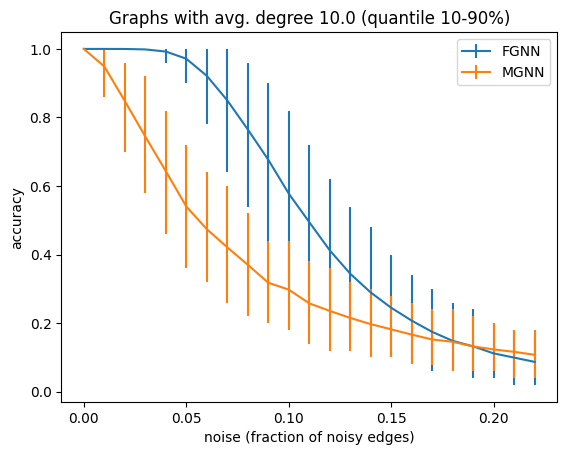

In [12]:
error_50 = np.abs(acc_2_error(mc_50,q50))
error_50MGNN = np.abs(acc_2_error(mc_50MGNN,q50MGNN))

plt.errorbar(list_noise,mc_50,yerr=error_50.T,label='FGNN');
plt.errorbar(list_noise,mc_50MGNN,yerr=error_50MGNN.T,label='MGNN');
plt.xlabel('noise (fraction of noisy edges)')
plt.ylabel('accuracy')
plt.title(f'Graphs with avg. degree {deg} (quantile {int(100*quant_low)}-{int(100*quant_up)}%)')
plt.legend()
plt.show()

## 1. Model Summary & Parameter Count

Let's inspect the architecture of the pretrained FGNN and count the number of trainable parameters.

In [11]:
# Model architecture
print("=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)
print(model)
print("\n" + "=" * 60)
print("PARAMETER COUNT")
print("=" * 60)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nConfig: {config_model['arch']}")
print(f"  - num_blocks: {config_model['arch']['num_blocks']}")
print(f"  - in_features: {config_model['arch']['in_features']}")
print(f"  - out_features: {config_model['arch']['out_features']}")
print(f"  - depth_of_mlp: {config_model['arch']['depth_of_mlp']}")
print(f"  - Device: {device}")

MODEL ARCHITECTURE
Siamese_Model(
  (node_embedder): Simple_Node_Embedding(
    (base_model): BaseModel(
      (reg_blocks): ModuleList(
        (0): RegularBlock(
          (mlp1): MlpBlock(
            (convs): ModuleList(
              (0): Conv2d(2, 64, kernel_size=(1, 1), stride=(1, 1))
              (1-2): 2 x Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
            )
          )
          (mlp2): MlpBlock(
            (convs): ModuleList(
              (0): Conv2d(2, 64, kernel_size=(1, 1), stride=(1, 1))
              (1-2): 2 x Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
            )
          )
          (mlp3): MlpBlock(
            (convs): ModuleList(
              (0): Conv2d(66, 64, kernel_size=(1, 1), stride=(1, 1))
              (1-2): 2 x Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
            )
          )
          (last_layer): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
        )
        (1): RegularBlock(
          (mlp1): MlpBlock(
      

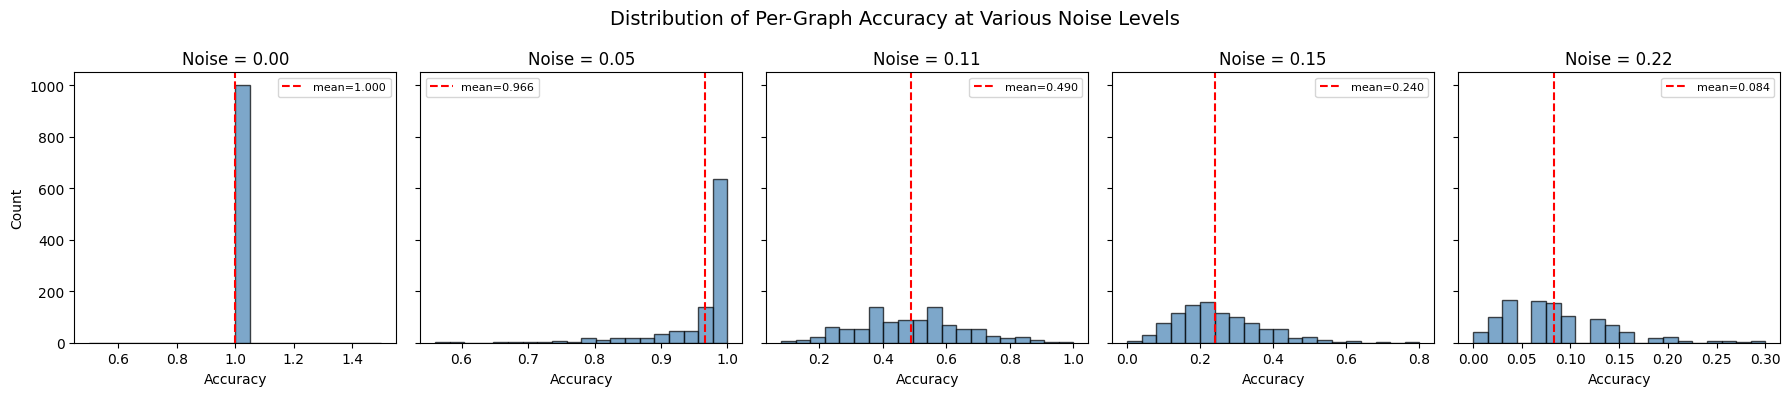

In [12]:
# Pick a few representative noise levels: low, medium (training noise), high
noise_indices = [0, 5, 11, 15, 22]  # indices into list_noise
fig, axes = plt.subplots(1, len(noise_indices), figsize=(18, 4), sharey=True)

for ax, idx in zip(axes, noise_indices):
    noise_val = list_noise[idx]
    acc_data = all_a[idx]
    ax.hist(acc_data, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(np.mean(acc_data), color='red', linestyle='--', label=f'mean={np.mean(acc_data):.3f}')
    ax.set_title(f'Noise = {noise_val:.2f}')
    ax.set_xlabel('Accuracy')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Count')
fig.suptitle('Distribution of Per-Graph Accuracy at Various Noise Levels', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Hungarian Algorithm vs Greedy Argmax Decoding

The model outputs a soft assignment matrix. We can decode it in two ways:
- **Hungarian algorithm** (**linear_sum_assignment**): optimal bipartite matching.
- **Greedy argmax**: simply take **argmax** per row, faster but suboptimal.

Let's compare them to see which method matters.

In [13]:
from toolbox.metrics import accuracy_max

def compute_all_with_metric(list_noise, args, path_dataset, model, metric_fn, bs=50):
    """Compute accuracy using a custom metric function."""
    num_batches = math.ceil(args['num_examples_test'] / bs)
    all_acc = np.zeros((len(list_noise), args['num_examples_test']))
    for i, noise in enumerate(list_noise):
        args['noise'] = noise
        gene_test = QAP_Generator('test', args, path_dataset)
        gene_test.load_dataset()
        test_loader = siamese_loader(gene_test, bs, gene_test.constant_n_vertices)
        _, all_acc[i, :] = all_losses_acc(test_loader, model, criterion, device, eval_score=metric_fn)
    return all_acc

# Compute accuracy with greedy argmax
all_a_argmax = compute_all_with_metric(list_noise, args, path_dataset, model, accuracy_max)

# Compute quantiles for argmax
mc_50_argmax, q50_argmax = compute_quant(all_a_argmax, quant_low=quant_low, quant_up=quant_up)

Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_1000_50_1.0_0.0_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_1000_50_1.0_0.01_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_1000_50_1.0_0.02_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_1000_50_1.0_0.03_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_1000_50_1.0_0.04_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_1000_50_1.0_0.05_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_1000_50_1.0_0.06_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_1000_50_1.0_0.07_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_1000_50_1.0_0.08_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_1000_50_1.0_0.09_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regul

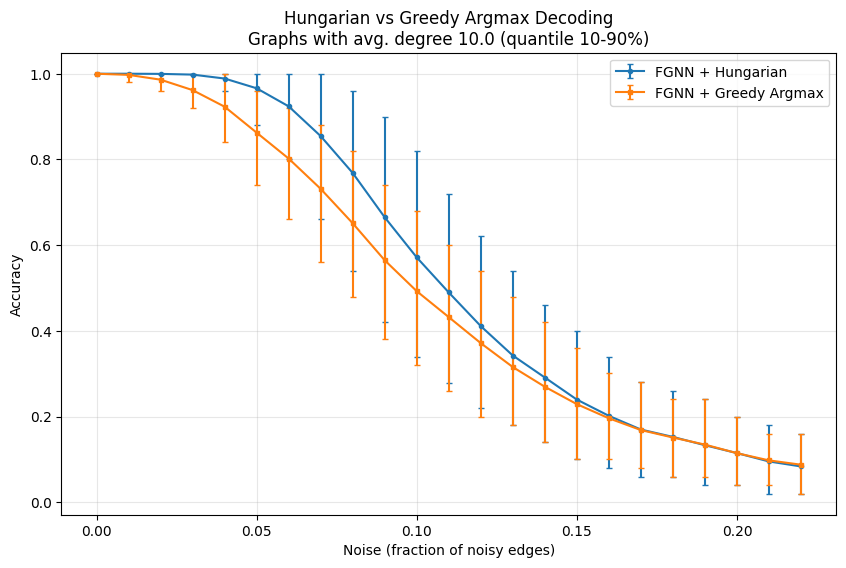


Accuracy gap (Hungarian - Argmax):
  Noise=0.00: Hungarian=1.000, Argmax=1.000, Gap=0.000
  Noise=0.04: Hungarian=0.989, Argmax=0.923, Gap=0.066
  Noise=0.08: Hungarian=0.768, Argmax=0.651, Gap=0.117
  Noise=0.12: Hungarian=0.411, Argmax=0.371, Gap=0.040
  Noise=0.16: Hungarian=0.202, Argmax=0.196, Gap=0.006
  Noise=0.20: Hungarian=0.115, Argmax=0.115, Gap=0.000


In [14]:
# Plot comparison: Hungarian vs Argmax
error_hungarian = abs(acc_2_error(mc_50, q50))
error_argmax = abs(acc_2_error(mc_50_argmax, q50_argmax))

plt.figure(figsize=(10, 6))
plt.errorbar(list_noise, mc_50, yerr=error_hungarian.T, label='FGNN + Hungarian', marker='o', markersize=3, capsize=2)
plt.errorbar(list_noise, mc_50_argmax, yerr=error_argmax.T, label='FGNN + Greedy Argmax', marker='s', markersize=3, capsize=2)
plt.xlabel('Noise (fraction of noisy edges)')
plt.ylabel('Accuracy')
plt.title(f'Hungarian vs Greedy Argmax Decoding\nGraphs with avg. degree {deg} (quantile {int(100*quant_low)}-{int(100*quant_up)}%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print the gap
print("\nAccuracy gap (Hungarian - Argmax):")
for i in range(0, len(list_noise), 4):
    print(f"  Noise={list_noise[i]:.2f}: Hungarian={mc_50[i]:.3f}, Argmax={mc_50_argmax[i]:.3f}, Gap={mc_50[i]-mc_50_argmax[i]:.3f}")

## 4. Random Baseline Comparison

How much better is the FGNN compared to a random permutation? 
For a graph with $n$ vertices, a random matching has expected accuracy $1/n$.

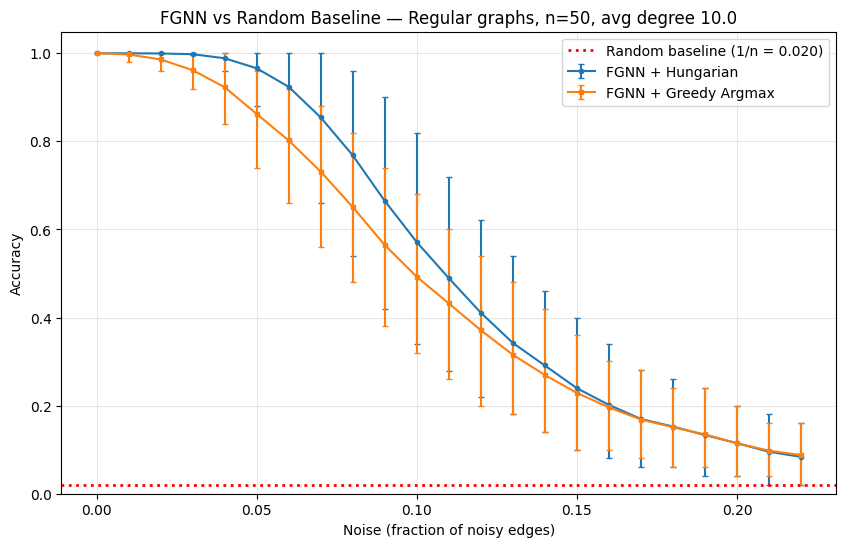


Improvement factor over random baseline (1/n = 0.0200):
  Noise=0.00: FGNN acc=1.000, improvement = 50.0x
  Noise=0.04: FGNN acc=0.989, improvement = 49.4x
  Noise=0.08: FGNN acc=0.768, improvement = 38.4x
  Noise=0.12: FGNN acc=0.411, improvement = 20.5x
  Noise=0.16: FGNN acc=0.202, improvement = 10.1x
  Noise=0.20: FGNN acc=0.115, improvement = 5.7x


In [15]:
n_vertices = args['n_vertices']
random_baseline = 1.0 / n_vertices  # Expected accuracy of random matching

plt.figure(figsize=(10, 6))
plt.errorbar(list_noise, mc_50, yerr=error_hungarian.T, label='FGNN + Hungarian', marker='o', markersize=3, capsize=2)
plt.errorbar(list_noise, mc_50_argmax, yerr=error_argmax.T, label='FGNN + Greedy Argmax', marker='s', markersize=3, capsize=2)
plt.axhline(y=random_baseline, color='red', linestyle=':', linewidth=2, label=f'Random baseline (1/n = {random_baseline:.3f})')
plt.xlabel('Noise (fraction of noisy edges)')
plt.ylabel('Accuracy')
plt.title(f'FGNN vs Random Baseline — Regular graphs, n={n_vertices}, avg degree {deg}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(bottom=0)
plt.show()

# Compute improvement factor over random
print(f"\nImprovement factor over random baseline (1/n = {random_baseline:.4f}):")
for i in range(0, len(list_noise), 4):
    factor = mc_50[i] / random_baseline
    print(f"  Noise={list_noise[i]:.2f}: FGNN acc={mc_50[i]:.3f}, improvement = {factor:.1f}x")

## 5. Generalization to Different Graph Types

The model was trained on Regular graphs. 
We will test how well it generalizes to **Erdos-Renyi** and **Barabasi-Albert** graphs, in order to evaluate out-of-distribution robustness.

In [16]:
import copy

# We'll test fewer noise points for speed
num_gen = 11
list_noise_gen = np.linspace(0, 0.22, num=num_gen)
num_ex_gen = 500  # fewer examples for faster evaluation

graph_types = {
    'Regular': {'generative_model': 'Regular', 'noise_model': 'ErdosRenyi'},
    'Erdos-Renyi': {'generative_model': 'ErdosRenyi', 'noise_model': 'ErdosRenyi'},
    'Barabasi-Albert': {'generative_model': 'BarabasiAlbert', 'noise_model': 'ErdosRenyi'},
}

results_by_type = {}

for gtype, gparams in graph_types.items():
    print(f"\n{'='*40}")
    print(f"Testing on {gtype} graphs...")
    print(f"{'='*40}")
    args_gen = copy.deepcopy(args)
    args_gen['generative_model'] = gparams['generative_model']
    args_gen['noise_model'] = gparams['noise_model']
    args_gen['num_examples_test'] = num_ex_gen
    
    num_batches = math.ceil(args_gen['num_examples_test'] / 50)
    all_acc_gen = np.zeros((num_gen, num_ex_gen))
    
    for i, noise_val in enumerate(list_noise_gen):
        args_gen['noise'] = noise_val
        gene_test = QAP_Generator('test', args_gen, path_dataset)
        gene_test.load_dataset()
        test_loader = siamese_loader(gene_test, 50, gene_test.constant_n_vertices)
        _, all_acc_gen[i, :] = all_losses_acc(test_loader, model, criterion, device,
                                               eval_score=accuracy_linear_assignment)
    
    mean_acc = np.mean(all_acc_gen, 1)
    results_by_type[gtype] = mean_acc
    print(f"  Mean accuracy at noise=0: {mean_acc[0]:.3f}")

print("\nDone!")


Testing on Regular graphs...
Creating dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_50_1.0_0.0_0.2/test.pkl


100%|██████████| 500/500 [00:00<00:00, 744.81it/s]


Saving dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_50_1.0_0.0_0.2/test.pkl
Creating dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_50_1.0_0.0_0.2/test_dgl.pkl
Converting data to DGL format


100%|██████████| 500/500 [00:00<00:00, 1213.50it/s]


Conversion ended.
Saving dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_50_1.0_0.0_0.2/test_dgl.pkl
Creating dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_50_1.0_0.022_0.2/test.pkl


...

Conversion ended.
Saving dataset at /Users/aminesaadi/data/QAP_BarabasiAlbert_ErdosRenyi_500_50_1.0_0.19799999999999998_0.2/test_dgl.pkl
Creating dataset at /Users/aminesaadi/data/QAP_BarabasiAlbert_ErdosRenyi_500_50_1.0_0.22_0.2/test.pkl


100%|██████████| 500/500 [00:00<00:00, 690.75it/s]


Saving dataset at /Users/aminesaadi/data/QAP_BarabasiAlbert_ErdosRenyi_500_50_1.0_0.22_0.2/test.pkl
Creating dataset at /Users/aminesaadi/data/QAP_BarabasiAlbert_ErdosRenyi_500_50_1.0_0.22_0.2/test_dgl.pkl
Converting data to DGL format


100%|██████████| 500/500 [00:00<00:00, 954.46it/s] 


Conversion ended.
Saving dataset at /Users/aminesaadi/data/QAP_BarabasiAlbert_ErdosRenyi_500_50_1.0_0.22_0.2/test_dgl.pkl
  Mean accuracy at noise=0: 1.000

Done!


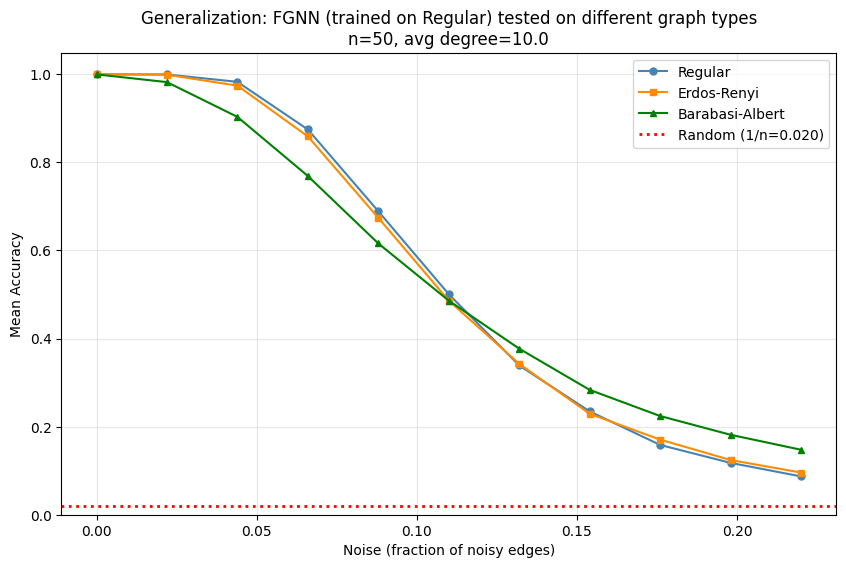

In [17]:
# Plot generalization results
plt.figure(figsize=(10, 6))
markers = ['o', 's', '^']
colors = ['steelblue', 'darkorange', 'green']

for (gtype, mean_acc), marker, color in zip(results_by_type.items(), markers, colors):
    plt.plot(list_noise_gen, mean_acc, marker=marker, markersize=5, label=gtype, color=color)

plt.axhline(y=random_baseline, color='red', linestyle=':', linewidth=2, label=f'Random (1/n={random_baseline:.3f})')
plt.xlabel('Noise (fraction of noisy edges)')
plt.ylabel('Mean Accuracy')
plt.title(f'Generalization: FGNN (trained on Regular) tested on different graph types\nn={n_vertices}, avg degree={deg}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(bottom=0)
plt.show()

## 6. Generalization to Different Graph Sizes

The model was trained on graphs with $n=50$ vertices. A key advantage of GNNs is size-generalization. Let's test the model on graphs with **20, 50, and 100 vertices** while keeping the same edge density.

In [18]:
graph_sizes = [20, 50, 100]
num_size = 11
list_noise_size = np.linspace(0, 0.22, num=num_size)
num_ex_size = 500

results_by_size = {}

for n in graph_sizes:
    print(f"\n{'='*40}")
    print(f"Testing with n_vertices = {n}...")
    print(f"{'='*40}")
    args_size = copy.deepcopy(args)
    args_size['n_vertices'] = n
    args_size['num_examples_test'] = num_ex_size
    
    all_acc_size = np.zeros((num_size, num_ex_size))
    
    for i, noise_val in enumerate(list_noise_size):
        args_size['noise'] = noise_val
        gene_test = QAP_Generator('test', args_size, path_dataset)
        gene_test.load_dataset()
        test_loader = siamese_loader(gene_test, 50, gene_test.constant_n_vertices)
        _, all_acc_size[i, :] = all_losses_acc(test_loader, model, criterion, device,
                                                eval_score=accuracy_linear_assignment)
    
    mean_acc = np.mean(all_acc_size, 1)
    results_by_size[n] = mean_acc
    avg_deg = n * args_size['edge_density']
    print(f"  n={n}, avg degree={avg_deg:.1f}, accuracy at noise=0: {mean_acc[0]:.3f}")

print("\nDone!")


Testing with n_vertices = 20...
Creating dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_20_1.0_0.0_0.2/test.pkl


100%|██████████| 500/500 [00:00<00:00, 1441.82it/s]


Saving dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_20_1.0_0.0_0.2/test.pkl
Creating dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_20_1.0_0.0_0.2/test_dgl.pkl
Converting data to DGL format


100%|██████████| 500/500 [00:00<00:00, 2279.95it/s]


Conversion ended.
Saving dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_20_1.0_0.0_0.2/test_dgl.pkl
Creating dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_20_1.0_0.022_0.2/test.pkl


...

Conversion ended.
Saving dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_100_1.0_0.19799999999999998_0.2/test_dgl.pkl
Creating dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_100_1.0_0.22_0.2/test.pkl


100%|██████████| 500/500 [00:05<00:00, 87.61it/s] 


Saving dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_100_1.0_0.22_0.2/test.pkl
Creating dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_100_1.0_0.22_0.2/test_dgl.pkl
Converting data to DGL format


100%|██████████| 500/500 [00:01<00:00, 268.49it/s]


Conversion ended.
Saving dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_100_1.0_0.22_0.2/test_dgl.pkl
  n=100, avg degree=20.0, accuracy at noise=0: 1.000

Done!


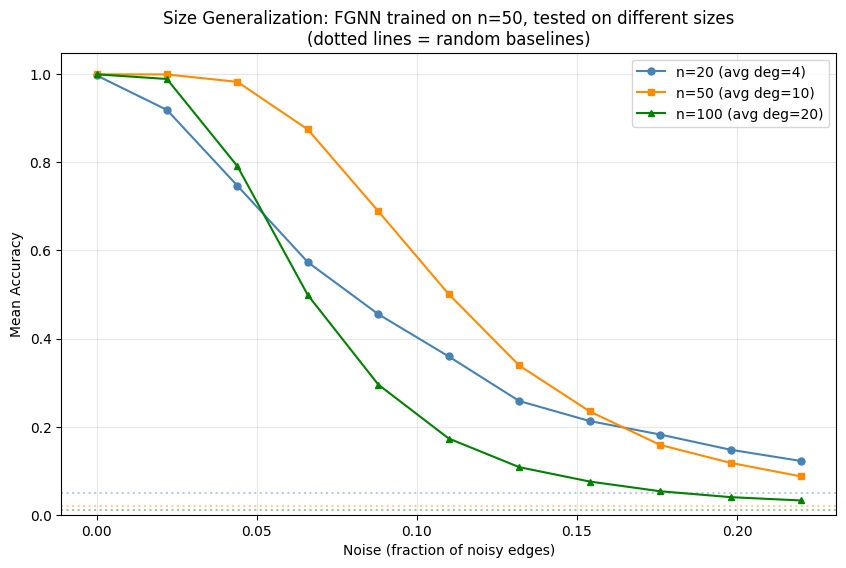

In [19]:
# Plot size generalization
plt.figure(figsize=(10, 6))
markers = ['o', 's', '^']
colors = ['steelblue', 'darkorange', 'green']

for (n, mean_acc), marker, color in zip(results_by_size.items(), markers, colors):
    avg_deg = n * args['edge_density']
    plt.plot(list_noise_size, mean_acc, marker=marker, markersize=5,
             label=f'n={n} (avg deg={avg_deg:.0f})', color=color)
    # Show random baseline for each size
    plt.axhline(y=1.0/n, color=color, linestyle=':', alpha=0.4)

plt.xlabel('Noise (fraction of noisy edges)')
plt.ylabel('Mean Accuracy')
plt.title('Size Generalization: FGNN trained on n=50, tested on different sizes\n(dotted lines = random baselines)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(bottom=0)
plt.show()

## 7. Visualizing the Similarity Matrix

Now we will look at what the model outputs: the similarity matrix for a single graph pair. 
A perfect prediction shows a strong diagonal pattern.

Creating dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_10_50_1.0_0.0_0.2/test.pkl


100%|██████████| 10/10 [00:00<00:00, 548.88it/s]


Saving dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_10_50_1.0_0.0_0.2/test.pkl
Creating dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_10_50_1.0_0.0_0.2/test_dgl.pkl
Converting data to DGL format


100%|██████████| 10/10 [00:00<00:00, 299.44it/s]


Conversion ended.
Saving dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_10_50_1.0_0.0_0.2/test_dgl.pkl
Creating dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_10_50_1.0_0.05_0.2/test.pkl


...

Conversion ended.
Saving dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_10_50_1.0_0.15_0.2/test_dgl.pkl
Creating dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_10_50_1.0_0.22_0.2/test.pkl


100%|██████████| 10/10 [00:00<00:00, 228.95it/s]

Saving dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_10_50_1.0_0.22_0.2/test.pkl
Creating dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_10_50_1.0_0.22_0.2/test_dgl.pkl
Converting data to DGL format



100%|██████████| 10/10 [00:00<00:00, 748.73it/s]


Conversion ended.
Saving dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_10_50_1.0_0.22_0.2/test_dgl.pkl


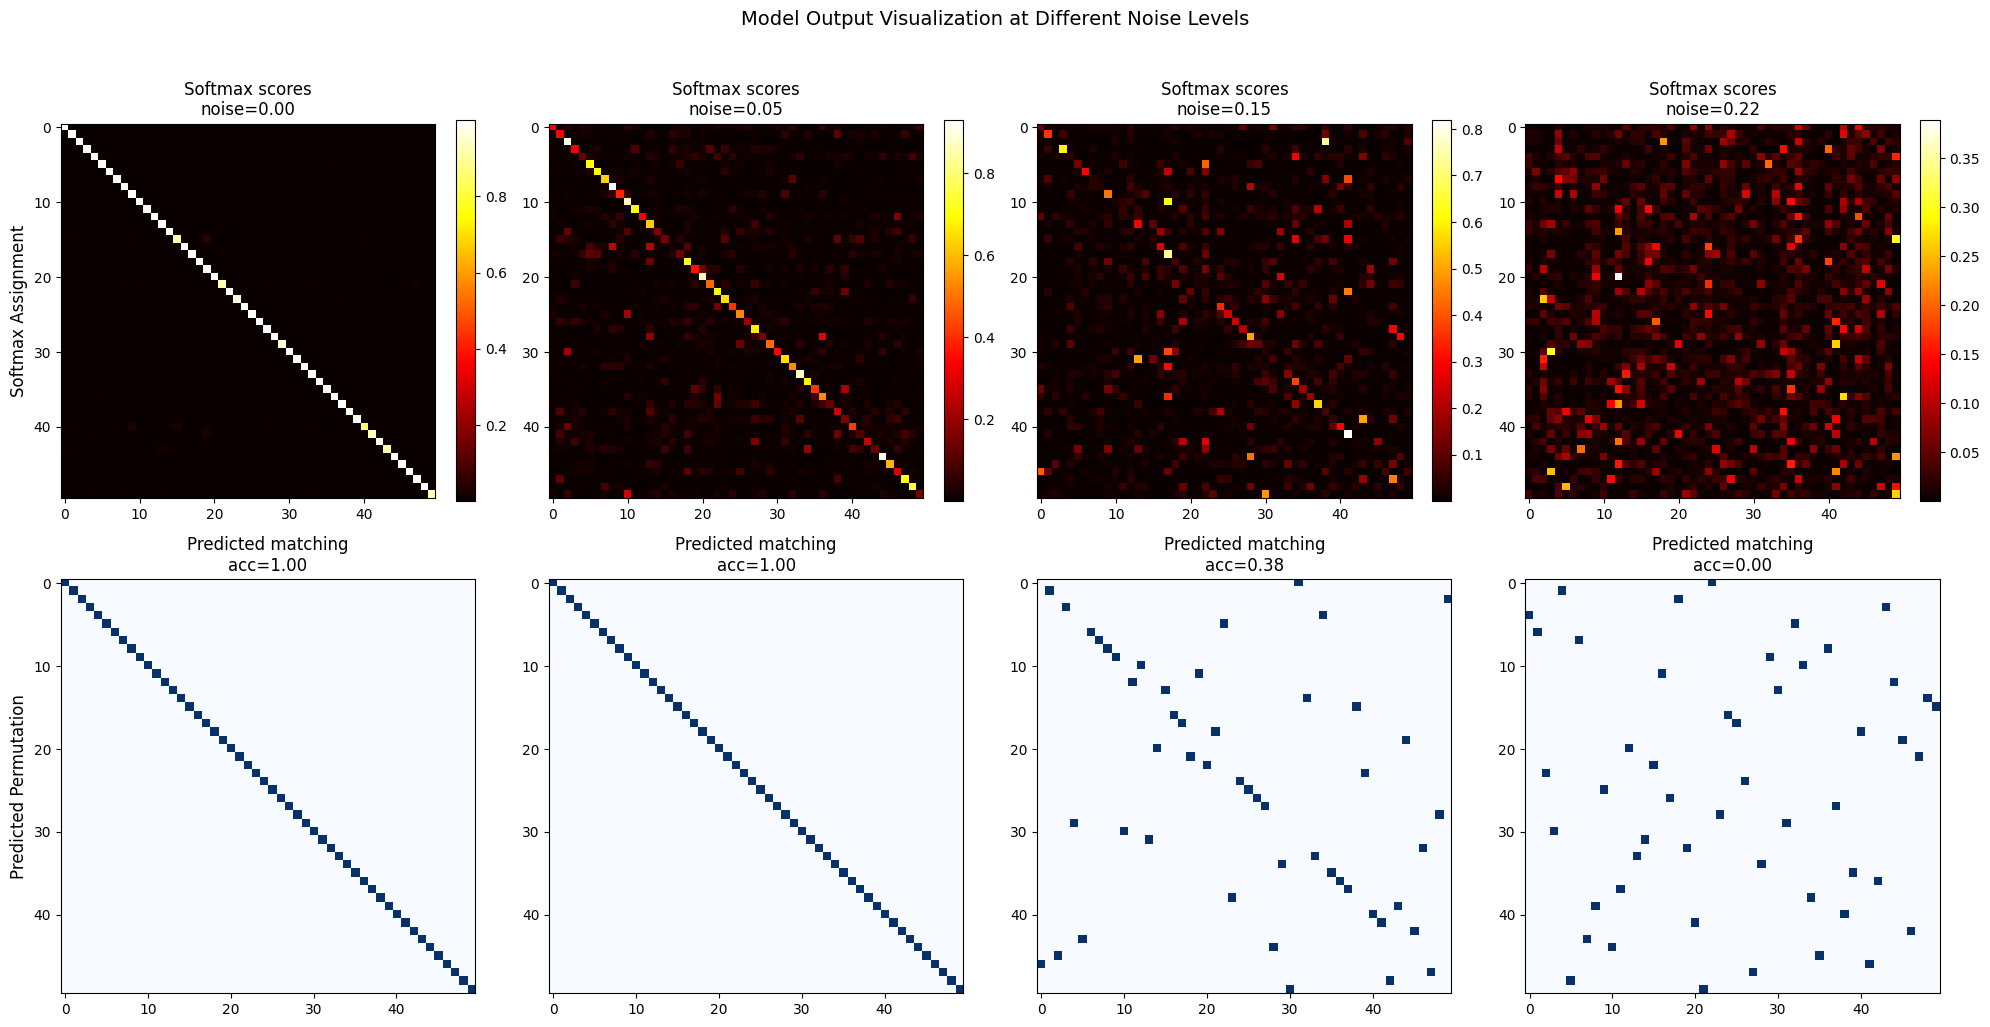

In [20]:
from scipy.optimize import linear_sum_assignment

# Generate one example at low noise and one at high noise
noise_levels_viz = [0.0, 0.05, 0.15, 0.22]
fig, axes = plt.subplots(2, len(noise_levels_viz), figsize=(20, 10))

for col, noise_val in enumerate(noise_levels_viz):
    args_viz = copy.deepcopy(args)
    args_viz['noise'] = noise_val
    args_viz['num_examples_test'] = 10
    gene_viz = QAP_Generator('test', args_viz, path_dataset)
    gene_viz.load_dataset()
    
    # Get a single example
    data, target = gene_viz[0]
    data_batch = data.unsqueeze(0).to(device)  # add batch dim
    
    with torch.no_grad():
        raw_scores = model(data_batch)
    
    # Raw scores
    scores_np = raw_scores[0].cpu().numpy()
    # Softmax scores
    soft_scores = torch.softmax(raw_scores, dim=-1)[0].cpu().numpy()
    
    # Compute matching
    cost = -torch.log_softmax(raw_scores, -1)[0].cpu().numpy()
    _, preds = linear_sum_assignment(cost)
    n = len(preds)
    acc = np.sum(preds == np.arange(n)) / n
    
    # Plot softmax scores
    im1 = axes[0, col].imshow(soft_scores, cmap='hot', aspect='equal')
    axes[0, col].set_title(f'Softmax scores\nnoise={noise_val:.2f}')
    plt.colorbar(im1, ax=axes[0, col], fraction=0.046)
    
    # Plot predicted permutation matrix
    perm_matrix = np.zeros((n, n))
    perm_matrix[np.arange(n), preds] = 1
    axes[1, col].imshow(perm_matrix, cmap='Blues', aspect='equal')
    axes[1, col].set_title(f'Predicted matching\nacc={acc:.2f}')

axes[0, 0].set_ylabel('Softmax Assignment', fontsize=12)
axes[1, 0].set_ylabel('Predicted Permutation', fontsize=12)
fig.suptitle('Model Output Visualization at Different Noise Levels', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Train New Models on Different Graph Types & Compare

Let's now train our own FGNN models directly on **Erdos-Renyi** and **Barabasi-Albert** graphs, then compare all three (third is regular pretrained model).

We use a lightweight setup for speed:
- 2000 training examples (vs 20000 in the original)
- 500 validation examples
- 10 epochs
- Same architecture (2 blocks, 64-dim, depth-3 MLPs)

In [21]:
from models.siamese_net import Siamese_Model
from models.base_model import Simple_Node_Embedding

def train_one_epoch(train_loader, model, optimizer, criterion, device):
    """Train for one epoch and return average loss."""
    model.train()
    total_loss = 0
    n_batches = 0
    for data, target in train_loader:
        data = data.to(device)
        target = target.to(device)
        
        optimizer.zero_grad()
        raw_scores = model(data)
        loss = criterion(raw_scores, target)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        n_batches += 1
    return total_loss / n_batches

def evaluate_accuracy(test_loader, model, criterion, device):
    """Evaluate model and return mean accuracy per graph."""
    model.eval()
    all_acc = []
    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device)
            target = target.to(device)
            raw_scores = model(data)
            acc = accuracy_linear_assignment(raw_scores, target, aggregate_score=False)
            all_acc += acc
    return np.array(all_acc)

def create_and_train_model(graph_type, noise_model, n_vertices, edge_density, 
                           training_noise, num_train, num_val, n_epochs, 
                           batch_size, lr, device, path_dataset):
    """Create a new Siamese FGNN and train it from scratch."""
    
    # Same architecture as the pretrained model
    new_model = Siamese_Model(
        original_features_num=2,
        num_blocks=2,
        in_features=64,
        out_features=64,
        depth_of_mlp=3
    ).to(device)
    
    new_criterion = triplet_loss()
    optimizer = torch.optim.Adam(new_model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3, verbose=False)
    
    param_count = sum(p.numel() for p in new_model.parameters())
    print(f"  Model parameters: {param_count:,}")
    
    # Generate training data
    train_args = {
        'generative_model': graph_type,
        'noise_model': noise_model,
        'edge_density': edge_density,
        'n_vertices': n_vertices,
        'vertex_proba': 1.0,
        'noise': training_noise,
        'num_examples_train': num_train,
        'num_examples_val': num_val,
    }
    
    print(f"  Generating training data ({num_train} examples)...")
    gene_train = QAP_Generator('train', train_args, path_dataset)
    gene_train.load_dataset()
    train_loader = siamese_loader(gene_train, batch_size, gene_train.constant_n_vertices)
    
    print(f"  Generating validation data ({num_val} examples)...")
    gene_val = QAP_Generator('val', train_args, path_dataset)
    gene_val.load_dataset()
    val_loader = siamese_loader(gene_val, batch_size, gene_val.constant_n_vertices)
    
    # Training loop
    print(f"  Training for {n_epochs} epochs...")
    train_losses = []
    val_accuracies = []
    best_acc = 0
    best_state = None
    
    for epoch in range(n_epochs):
        loss = train_one_epoch(train_loader, new_model, optimizer, new_criterion, device)
        train_losses.append(loss)
        
        val_acc = evaluate_accuracy(val_loader, new_model, new_criterion, device)
        mean_val_acc = np.mean(val_acc)
        val_accuracies.append(mean_val_acc)
        
        scheduler.step(loss)
        
        if mean_val_acc > best_acc:
            best_acc = mean_val_acc
            best_state = {k: v.clone() for k, v in new_model.state_dict().items()}
        
        print(f"    Epoch {epoch+1}/{n_epochs} — Loss: {loss:.4f}, Val Acc: {mean_val_acc:.3f}")
    
    # Load best model
    if best_state is not None:
        new_model.load_state_dict(best_state)
    print(f"  Best validation accuracy: {best_acc:.3f}")
    
    return new_model, train_losses, val_accuracies

In [ ]:
# Training configuration
TRAIN_CONFIG = {
    'n_vertices': 50,
    'edge_density': 0.2,
    'training_noise': 0.15,
    'num_train': 2000,
    'num_val': 500,
    'n_epochs': 10,
    'batch_size': 32,
    'lr': 1e-3,
}

# Dictionary to hold all trained models
trained_models = {
    'Regular (pretrained)': model,  # The pretrained model from GitHub
}

# Train on Erdos-Renyi
print("=" * 60)
print("TRAINING MODEL ON ERDOS-RENYI GRAPHS")
print("=" * 60)
er_model, er_losses, er_val_acc = create_and_train_model(
    graph_type='ErdosRenyi',
    noise_model='ErdosRenyi',
    device=device,
    path_dataset=path_dataset,
    **TRAIN_CONFIG
)
trained_models['Erdos-Renyi (trained)'] = er_model

# Train on Barabasi-Albert
print("\n" + "=" * 60)
print("TRAINING MODEL ON BARABASI-ALBERT GRAPHS")
print("=" * 60)
ba_model, ba_losses, ba_val_acc = create_and_train_model(
    graph_type='BarabasiAlbert',
    noise_model='ErdosRenyi',
    device=device,
    path_dataset=path_dataset,
    **TRAIN_CONFIG
)
trained_models['Barabasi-Albert (trained)'] = ba_model

print("\n" + "=" * 60)
print("ALL MODELS READY!")
print("=" * 60)
for name in trained_models:
    print(f"  - {name}")

TRAINING MODEL ON ERDOS-RENYI GRAPHS
  Model parameters: 79,488
  Generating training data (2000 examples)...
Creating dataset at /Users/aminesaadi/data/QAP_ErdosRenyi_ErdosRenyi_2000_50_1.0_0.15_0.2/train.pkl


100%|██████████| 2000/2000 [00:03<00:00, 557.69it/s]


Saving dataset at /Users/aminesaadi/data/QAP_ErdosRenyi_ErdosRenyi_2000_50_1.0_0.15_0.2/train.pkl
Creating dataset at /Users/aminesaadi/data/QAP_ErdosRenyi_ErdosRenyi_2000_50_1.0_0.15_0.2/train_dgl.pkl
Converting data to DGL format


100%|██████████| 2000/2000 [00:02<00:00, 700.56it/s]


Conversion ended.
Saving dataset at /Users/aminesaadi/data/QAP_ErdosRenyi_ErdosRenyi_2000_50_1.0_0.15_0.2/train_dgl.pkl
  Generating validation data (500 examples)...
Creating dataset at /Users/aminesaadi/data/QAP_ErdosRenyi_ErdosRenyi_500_50_1.0_0.15_0.2/val.pkl


...

Conversion ended.
Saving dataset at /Users/aminesaadi/data/QAP_BarabasiAlbert_ErdosRenyi_2000_50_1.0_0.15_0.2/train_dgl.pkl
  Generating validation data (500 examples)...
Creating dataset at /Users/aminesaadi/data/QAP_BarabasiAlbert_ErdosRenyi_500_50_1.0_0.15_0.2/val.pkl


100%|██████████| 500/500 [00:00<00:00, 773.60it/s]


Saving dataset at /Users/aminesaadi/data/QAP_BarabasiAlbert_ErdosRenyi_500_50_1.0_0.15_0.2/val.pkl
Creating dataset at /Users/aminesaadi/data/QAP_BarabasiAlbert_ErdosRenyi_500_50_1.0_0.15_0.2/val_dgl.pkl
Converting data to DGL format


100%|██████████| 500/500 [00:00<00:00, 1267.45it/s]


Conversion ended.
Saving dataset at /Users/aminesaadi/data/QAP_BarabasiAlbert_ErdosRenyi_500_50_1.0_0.15_0.2/val_dgl.pkl
  Training for 10 epochs...
    Epoch 1/10 — Loss: 3.4446, Val Acc: 0.130
    Epoch 2/10 — Loss: 3.1753, Val Acc: 0.171
    Epoch 3/10 — Loss: 2.9932, Val Acc: 0.198
    Epoch 4/10 — Loss: 2.8002, Val Acc: 0.263
    Epoch 5/10 — Loss: 2.6053, Val Acc: 0.350
    Epoch 6/10 — Loss: 2.3793, Val Acc: 0.435
    Epoch 7/10 — Loss: 2.1644, Val Acc: 0.484
    Epoch 8/10 — Loss: 2.0580, Val Acc: 0.519
    Epoch 9/10 — Loss: 1.9587, Val Acc: 0.534
    Epoch 10/10 — Loss: 1.9041, Val Acc: 0.547
  Best validation accuracy: 0.547

ALL MODELS READY!
  - Regular (pretrained)
  - Erdos-Renyi (trained)
  - Barabasi-Albert (trained)


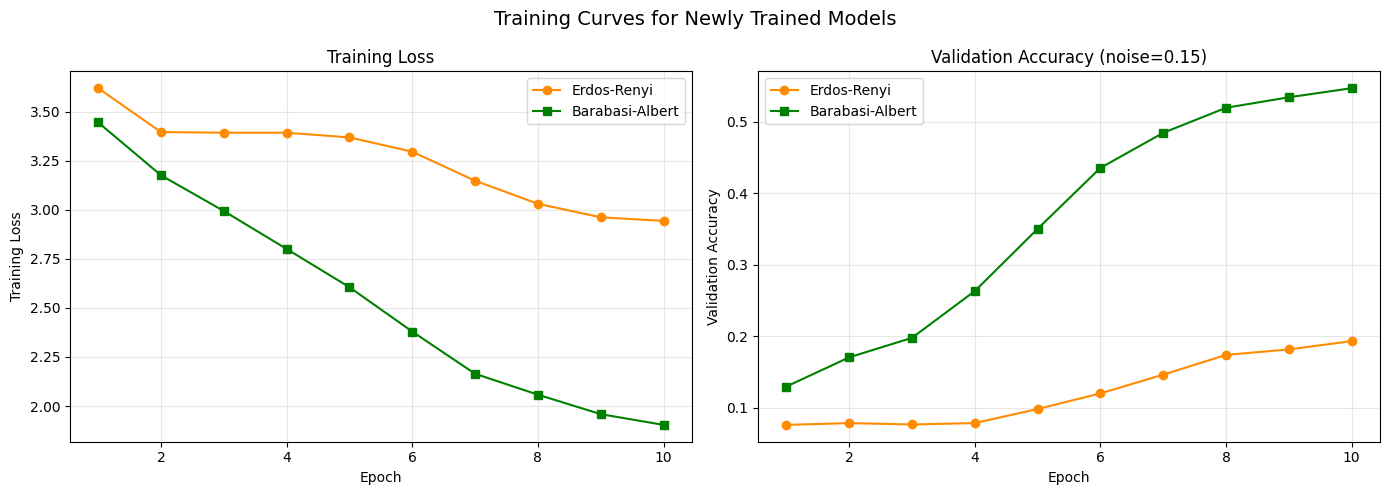

In [23]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(range(1, len(er_losses)+1), er_losses, 'o-', label='Erdos-Renyi', color='darkorange')
axes[0].plot(range(1, len(ba_losses)+1), ba_losses, 's-', label='Barabasi-Albert', color='green')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation accuracy curves
axes[1].plot(range(1, len(er_val_acc)+1), er_val_acc, 'o-', label='Erdos-Renyi', color='darkorange')
axes[1].plot(range(1, len(ba_val_acc)+1), ba_val_acc, 's-', label='Barabasi-Albert', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy (noise=0.15)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle('Training Curves for Newly Trained Models', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Cross-Evaluation: Every Model on Every Graph Type

Now an interesting experiment: We test **each model** on **each graph type**. This creates a 3×3 comparison matrix showing:

- Does a model perform best on the graph type it was trained on?
- Which model generalizes best?

In [24]:
# Cross-evaluation: each model on each graph type
num_cross = 11
list_noise_cross = np.linspace(0, 0.22, num=num_cross)
num_ex_cross = 500

test_graph_types = ['Regular', 'ErdosRenyi', 'BarabasiAlbert']
test_graph_labels = ['Regular', 'Erdos-Renyi', 'Barabasi-Albert']

# results_cross[model_name][graph_type] = mean_acc array
results_cross = {}

for model_name, mdl in trained_models.items():
    results_cross[model_name] = {}
    mdl.eval()
    
    for gtype, glabel in zip(test_graph_types, test_graph_labels):
        print(f"Testing '{model_name}' on {glabel} graphs...")
        
        args_cross = copy.deepcopy(args)
        args_cross['generative_model'] = gtype
        args_cross['noise_model'] = 'ErdosRenyi'
        args_cross['num_examples_test'] = num_ex_cross
        
        all_acc_cross = np.zeros((num_cross, num_ex_cross))
        
        for i, noise_val in enumerate(list_noise_cross):
            args_cross['noise'] = noise_val
            gene_test = QAP_Generator('test', args_cross, path_dataset)
            gene_test.load_dataset()
            test_loader = siamese_loader(gene_test, 50, gene_test.constant_n_vertices)
            _, all_acc_cross[i, :] = all_losses_acc(
                test_loader, mdl, criterion, device,
                eval_score=accuracy_linear_assignment
            )
        
        results_cross[model_name][glabel] = np.mean(all_acc_cross, 1)

print("\nCross-evaluation complete!")

Testing 'Regular (pretrained)' on Regular graphs...
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_50_1.0_0.0_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_50_1.0_0.022_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_50_1.0_0.044_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_50_1.0_0.066_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_50_1.0_0.088_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_50_1.0_0.10999999999999999_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_50_1.0_0.132_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_50_1.0_0.154_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_50_1.0_0.176_0.2/test.pkl
Reading dataset at /Users/aminesaadi/data/QAP_Regular_ErdosRenyi_500_50_1.0_0.197

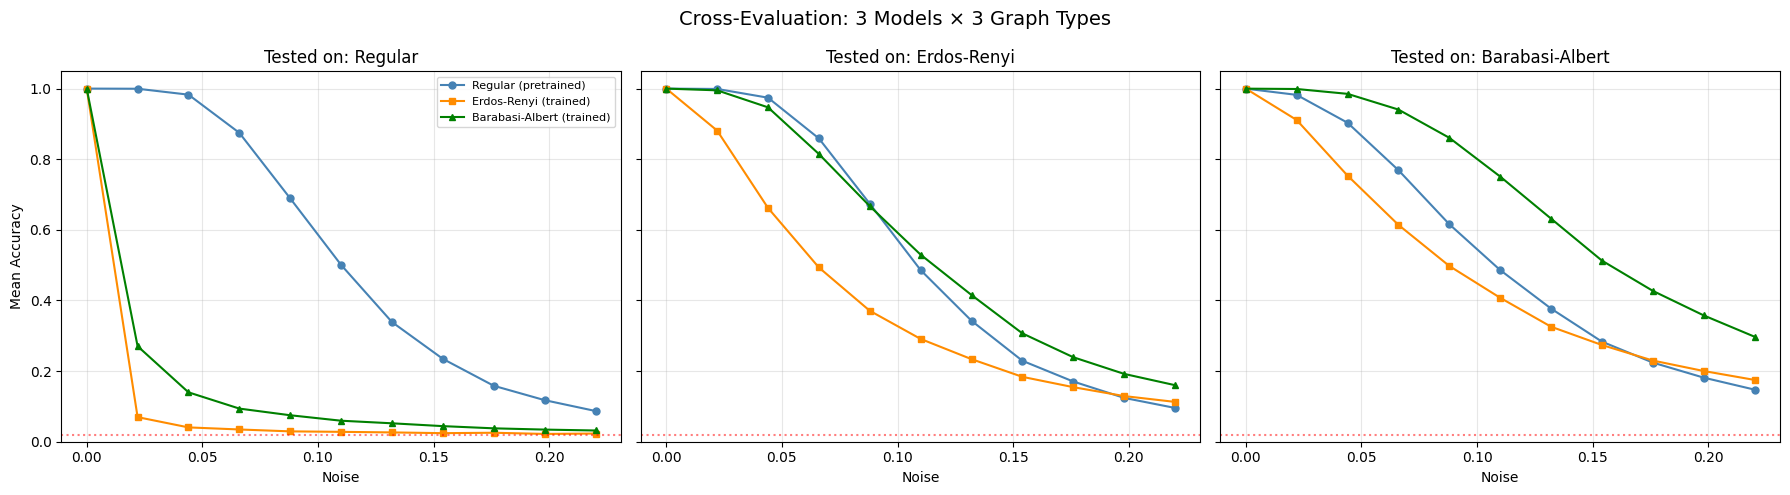

In [25]:
# Plot: One subplot per TEST graph type, all models compared
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

model_colors = {
    'Regular (pretrained)': 'steelblue',
    'Erdos-Renyi (trained)': 'darkorange',
    'Barabasi-Albert (trained)': 'green',
}
model_markers = {
    'Regular (pretrained)': 'o',
    'Erdos-Renyi (trained)': 's',
    'Barabasi-Albert (trained)': '^',
}

for col, glabel in enumerate(test_graph_labels):
    ax = axes[col]
    for model_name in trained_models:
        acc = results_cross[model_name][glabel]
        ax.plot(list_noise_cross, acc,
                marker=model_markers[model_name], markersize=5,
                color=model_colors[model_name],
                label=model_name)
    
    ax.axhline(y=random_baseline, color='red', linestyle=':', alpha=0.5)
    ax.set_xlabel('Noise')
    ax.set_title(f'Tested on: {glabel}')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

axes[0].set_ylabel('Mean Accuracy')
axes[0].legend(fontsize=8, loc='upper right')
fig.suptitle('Cross-Evaluation: 3 Models × 3 Graph Types', fontsize=14)
plt.tight_layout()
plt.show()


Cross-Evaluation Summary (accuracy at noise = 0.11)
Tested on →                Regular  Erdos-Renyi  Barabasi-Albert
Trained on ↓                                                    
Regular (pretrained)         0.501        0.486            0.486
Erdos-Renyi (trained)        0.028        0.291            0.408
Barabasi-Albert (trained)    0.059        0.530            0.751

(Diagonal-like entries = in-distribution, off-diagonal = out-of-distribution)


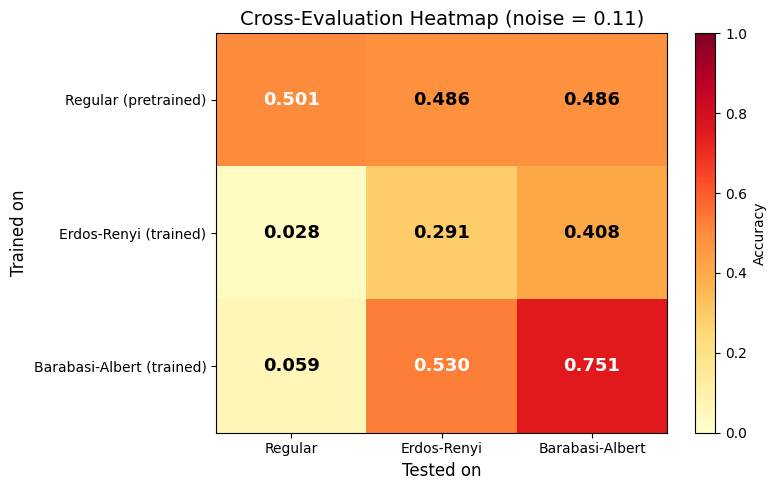

In [26]:
# Summary heatmap: accuracy at noise=0.10 for each (model, graph_type) pair
import pandas as pd

noise_idx = 5  # index closest to noise=0.10
noise_val_summary = list_noise_cross[noise_idx]

summary_data = {}
for model_name in trained_models:
    summary_data[model_name] = {}
    for glabel in test_graph_labels:
        summary_data[model_name][glabel] = results_cross[model_name][glabel][noise_idx]

df_summary = pd.DataFrame(summary_data).T
df_summary.columns.name = 'Tested on →'
df_summary.index.name = 'Trained on ↓'

print(f"\nCross-Evaluation Summary (accuracy at noise = {noise_val_summary:.2f})")
print("=" * 60)
print(df_summary.to_string(float_format='{:.3f}'.format))
print("\n(Diagonal-like entries = in-distribution, off-diagonal = out-of-distribution)")

# Heatmap
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(df_summary.values, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')

ax.set_xticks(range(len(test_graph_labels)))
ax.set_xticklabels(test_graph_labels, fontsize=10)
ax.set_yticks(range(len(trained_models)))
ax.set_yticklabels(list(trained_models.keys()), fontsize=10)
ax.set_xlabel('Tested on', fontsize=12)
ax.set_ylabel('Trained on', fontsize=12)

# Add text annotations
for i in range(len(trained_models)):
    for j in range(len(test_graph_labels)):
        val = df_summary.values[i, j]
        color = 'white' if val > 0.5 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', color=color, fontsize=13, fontweight='bold')

plt.colorbar(im, label='Accuracy')
ax.set_title(f'Cross-Evaluation Heatmap (noise = {noise_val_summary:.2f})', fontsize=14)
plt.tight_layout()
plt.show()